In [202]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [185]:
noisyData=pd.read_excel(r'C:\Users\sai.venkat\OneDrive\DataScience\Python\PYTHON_BIGINNER\Libraries\EDA\Random_NoisyData.xlsx')
noisyData

,Date,Product,Category,Sales,Quantity,Profit
0,2024-01-01,Product A,Electronics,305.17,NaN,NaN
1,2024-01-02,Product B,Furniture,176.45,4.0,54.78
2,2024-01-03,Product C,Clothing,NaN,1.0,74.03
3,2024-01-04,Product D,Groceries,213.12,8.0,54.36
4,2024-01-05,Product A,Electronics,586.30,1.0,72.70
...,...,...,...,...,...,...
95,2024-04-05,Product D,Groceries,511.45,3.0,92.92
96,2024-04-06,Product A,Electronics,237.37,2.0,26.76
97,2024-04-07,Product B,Furniture,483.49,2.0,28.59
98,2024-04-08,Product C,Clothing,508.94,6.0,34.44


# Data Cleansing    

In [186]:
noisyData.isnull().sum()

Date         0
Product      0
Category     0
Sales       10
Quantity    10
Profit      10
dtype: int64

In [187]:
# Data Cleansing --> Product

In [188]:
# Replaces ?, #,^ with nan
noisyData['Product'] = noisyData['Product'].replace(r'.*[?#^].*', np.nan, regex=True)
noisyData['Product'].isna().sum()

noisyData['Product']=noisyData['Product'].fillna(noisyData['Product'].mode()[0])
noisyData['Product'].mode()[0]


'Product B'

In [189]:
noisyData['Sales'].isna().sum()

noisyData['Sales']=noisyData['Sales'].fillna(noisyData['Sales'].mean())
noisyData['Sales'].mean()


509.68

In [190]:
noisyData['Quantity'].isna().sum()
noisyData['Quantity'].mean()

noisyData['Quantity']=noisyData['Quantity'].fillna(noisyData['Quantity'].mean())
noisyData['Quantity'].mean()





4.5888888888888895

In [191]:
noisyData['Profit'].isna().sum()
noisyData['Profit'].mean()


noisyData['Profit']=noisyData['Profit'].fillna(noisyData['Profit'].mean())
noisyData['Profit'].mean()






49.09877777777778

In [192]:
noisyData['Product'][8]

'Product B'

In [193]:
cleanedData=noisyData.copy()
cleanedData.to_csv('CleanedData_ChatGPT_WithIndex.csv')
cleanedData.to_csv('CleanedData_ChatGPT_WithoutIndex.csv',index=False)

In [194]:
cleanedData['Product']=cleanedData['Product'].astype('category')
cleanedData['Category']=cleanedData['Category'].astype("category")


In [199]:
cleanedData['Sales']=cleanedData['Sales'].astype('float')
cleanedData['Quantity']=cleanedData['Quantity'].astype("float")
cleanedData['Profit']=cleanedData['Profit'].astype('float')


In [200]:
cleanedData.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      100 non-null    datetime64[ns]
 1   Product   100 non-null    category      
 2   Category  100 non-null    category      
 3   Sales     100 non-null    float64       
 4   Quantity  100 non-null    float64       
 5   Profit    100 non-null    float64       
dtypes: category(2), datetime64[ns](1), float64(3)
memory usage: 3.9 KB


In [201]:
import os
# To get Path of the file being stored 
os.getcwd()

'c:\\Users\\sai.venkat\\OneDrive\\DataScience\\Python\\PYTHON_BIGINNER\\Libraries\\EDA'

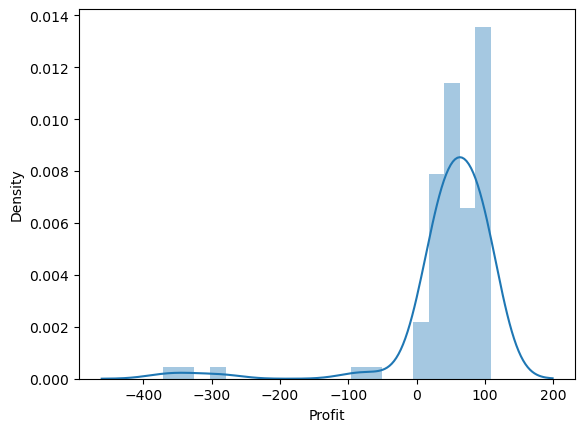

In [203]:
#Univariant Analyis
vis1=sns.distplot(cleanedData['Profit'])
plt.show()

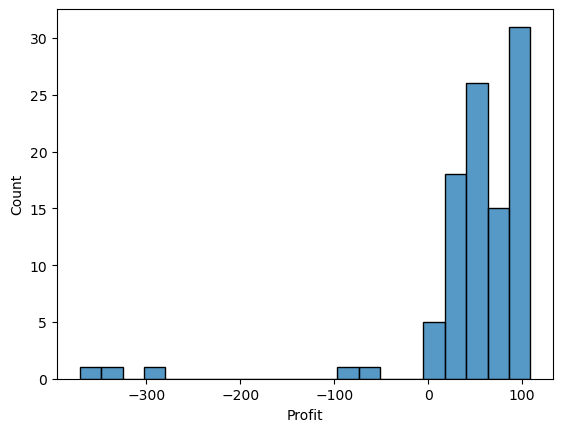

In [ ]:

# Outliers 
vis2=sns.histplot(cleanedData['Profit'])
plt.show()

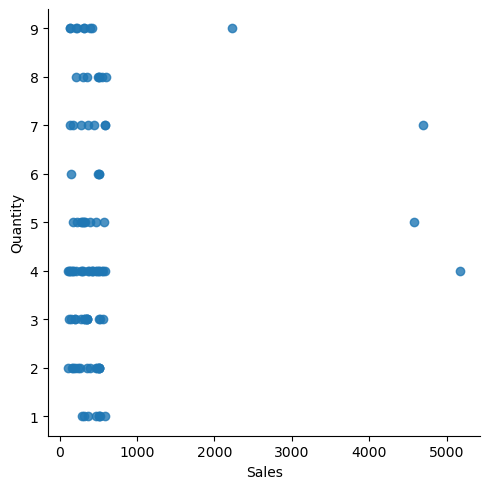

In [208]:
# Bivariant Analyis
vis4=sns.lmplot(data=cleanedData,x='Sales',y='Quantity',fit_reg=False)

In [209]:
cleanedData.columns

Index(['Date', 'Product', 'Category', 'Sales', 'Quantity', 'Profit'], dtype='object')

In [218]:
X_IndependentVariable=cleanedData[['Date','Product','Sales','Quantity','Profit']]
Y_DependentVariables=cleanedData[['Category']]

In [217]:
X_IndependentVariable.columns

Index(['Date', 'Product', 'Sales', 'Quantity', 'Profit'], dtype='object')

In [215]:
Y_DependentVariables.columns

Index(['Category'], dtype='object')

In [223]:
# Imputation is not done for Numeric cols
imputation=pd.get_dummies(X_IndependentVariable)
imputation

,Date,Sales,Quantity,Profit,Product_Product A,Product_Product B,Product_Product C,Product_Product D
0,2024-01-01,305.0,4.0,49.0,True,False,False,False
1,2024-01-02,176.0,4.0,54.0,False,True,False,False
2,2024-01-03,509.0,1.0,74.0,False,False,True,False
3,2024-01-04,213.0,8.0,54.0,False,False,False,True
4,2024-01-05,586.0,1.0,72.0,True,False,False,False
...,...,...,...,...,...,...,...,...
95,2024-04-05,511.0,3.0,92.0,False,False,False,True
96,2024-04-06,237.0,2.0,26.0,True,False,False,False
97,2024-04-07,483.0,2.0,28.0,False,True,False,False
98,2024-04-08,508.0,6.0,34.0,False,False,True,False


In [224]:
# Imputation is not done for Numeric cols
imputation=pd.get_dummies(X_IndependentVariable,dtype=int)
imputation

,Date,Sales,Quantity,Profit,Product_Product A,Product_Product B,Product_Product C,Product_Product D
0,2024-01-01,305.0,4.0,49.0,1,0,0,0
1,2024-01-02,176.0,4.0,54.0,0,1,0,0
2,2024-01-03,509.0,1.0,74.0,0,0,1,0
3,2024-01-04,213.0,8.0,54.0,0,0,0,1
4,2024-01-05,586.0,1.0,72.0,1,0,0,0
...,...,...,...,...,...,...,...,...
95,2024-04-05,511.0,3.0,92.0,0,0,0,1
96,2024-04-06,237.0,2.0,26.0,1,0,0,0
97,2024-04-07,483.0,2.0,28.0,0,1,0,0
98,2024-04-08,508.0,6.0,34.0,0,0,1,0
